# 2D Soft Body Dynamics: Implicit Integration

This tutorial extends the explicit solver with **implicit time integration** using sparse linear solvers.

**Learning Goals:**
1. Understand implicit (backward) Euler time integration
2. Build sparse stiffness matrices on GPU
3. Solve linear systems with BiCGSTAB
4. Compare explicit vs implicit stability

**Key Demonstration:** The SAME stiff springs that explode with explicit work perfectly with implicit!

**Prerequisites:** Complete [01_explicit.ipynb](01_explicit.ipynb) first!

## 1. Why Implicit Integration?

**Problem with Explicit:** Stiff springs require tiny timesteps for stability ($\Delta t \propto 1/\sqrt{k}$)

**Implicit Euler** evaluates forces at the **future** time:
$$\mathbf{v}_{n+1} = \mathbf{v}_n + \Delta t \cdot \mathbf{M}^{-1} \mathbf{f}(\mathbf{x}_{n+1})$$

This requires solving a nonlinear system, which we linearize:
$$(\mathbf{M} - \Delta t^2 \mathbf{K})\Delta\mathbf{v} = \Delta t \cdot \mathbf{f}$$

where $\mathbf{K} = -\partial\mathbf{f}/\partial\mathbf{x}$ is the stiffness matrix.

**Result:** Unconditionally stable → **much larger timesteps!**

---
## 2. Implementation

Step-by-step GPU implementation using Warp's sparse linear solvers.

In [1]:
# Step 1: Imports
import numpy as np
import warp as wp
from warp.optim.linear import bicgstab, preconditioner
from warp.sparse import bsr_zeros, bsr_set_from_triplets
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import Image
import time

# Import shared utilities from Part 1
from utils import (
    State, Model, SolverExplicit,
    eval_spring_2d, apply_boundary_2d, integrate_particles_2d, finalize_velocity_2d,
    run_simulation, get_colors, create_spring_colormap
)

wp.init()
print(f"Warp {wp.__version__} on {wp.get_device()}")

Warp 1.11.0.dev20251123 initialized:
   Git commit: 8b8f0b85ca54c0026574f834764e26615056aef6
   CUDA Toolkit 12.8, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA L40S" (44 GiB, sm_89, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.11.0.dev20251123
Warp 1.11.0.dev20251123 on cuda:0


### 2.1 Spring Force Kernel (from Part 1)

Same Hooke's Law implementation as before - imported from `utils.py`.

In [2]:
# Step 2: Spring Force Kernel (imported from utils.py - same as Part 1)
# The eval_spring_2d kernel was already imported above from utils.py
# See 01_explicit.ipynb for the full implementation details.
print("Spring kernel imported from utils.py")

Spring kernel imported from utils.py


### 2.2 Implicit Solver Kernels

Build sparse system matrix $\mathbf{A} = \mathbf{M} - \Delta t^2 \mathbf{K}$

We use Block Sparse Row (BSR) format with 2×2 blocks (one per particle pair).

In [3]:
# Step 3: Implicit Solver Kernels
@wp.kernel
def build_spring_matrix_2d(
    rows: wp.array(dtype=wp.int32), cols: wp.array(dtype=wp.int32),
    values: wp.array(dtype=wp.mat22f), indices: wp.array(dtype=int),
    spring_stiffness: wp.array(dtype=float), spring_damping: wp.array(dtype=float),
    dt: float, mass: float, Minv: float
):
    """Build stiffness matrix contributions from springs.
    
    For system (M + dt²K)Δv = dt*f, each spring contributes:
    - Diagonal blocks: mass + dt²*k (self-stiffness, positive)
    - Off-diagonal blocks: -dt²*k (coupling between particles, negative)
    """
    tid = wp.tid()
    i = indices[tid * 2 + 0]
    j = indices[tid * 2 + 1]
    k = spring_stiffness[tid]
    d = spring_damping[tid]
    dt2 = dt * dt
    
    # Diagonal: M + dt²K (positive-definite)
    diag = mass + dt * d + dt2 * k
    block_diag = wp.mat22f(diag, 0.0, 0.0, diag)
    
    # Off-diagonal: -dt²K coupling (negative)
    block_off = wp.mat22f(-dt2 * k, 0.0, 0.0, -dt2 * k)
    
    # Store 4 blocks per spring
    base = tid * 4
    rows[base] = i;   cols[base] = i;   values[base] = block_diag
    rows[base+1] = j; cols[base+1] = j; values[base+1] = block_diag
    rows[base+2] = i; cols[base+2] = j; values[base+2] = block_off
    rows[base+3] = j; cols[base+3] = i; values[base+3] = block_off


@wp.kernel
def update_state_2d(dv: wp.array(dtype=wp.vec2), dt: float,
                    pos_in: wp.array(dtype=wp.vec2), vel_in: wp.array(dtype=wp.vec2),
                    pos_out: wp.array(dtype=wp.vec2), vel_out: wp.array(dtype=wp.vec2)):
    tid = wp.tid()
    vel = vel_in[tid] + dv[tid]
    pos_out[tid] = pos_in[tid] + vel * dt
    vel_out[tid] = vel


@wp.kernel
def eval_gravity_2d(gravity: wp.vec2, forces: wp.array(dtype=wp.vec2)):
    tid = wp.tid()
    forces[tid] = gravity


@wp.kernel
def apply_boundary_2d(x: wp.array(dtype=wp.vec2), v: wp.array(dtype=wp.vec2), boxsize: float):
    tid = wp.tid()
    pos = x[tid]
    vel = v[tid]
    if pos[0] < 0.0:
        pos = wp.vec2(-pos[0], pos[1])
        vel = wp.vec2(-vel[0], vel[1])
    elif pos[0] > boxsize:
        pos = wp.vec2(2.0*boxsize - pos[0], pos[1])
        vel = wp.vec2(-vel[0], vel[1])
    if pos[1] < 0.0:
        pos = wp.vec2(pos[0], -pos[1])
        vel = wp.vec2(vel[0], -vel[1])
    elif pos[1] > boxsize:
        pos = wp.vec2(pos[0], 2.0*boxsize - pos[1])
        vel = wp.vec2(vel[0], -vel[1])
    x[tid] = pos
    v[tid] = vel

print("Implicit kernels defined")

Implicit kernels defined


### 2.3 Data Structures

State and Model classes (same as Part 1) - imported from `utils.py`.

In [4]:
# Step 4: State and Model Classes (imported from utils.py - same as Part 1)
# The State and Model classes were already imported above from utils.py
# See 01_explicit.ipynb for the full implementation details.
print("State and Model imported from utils.py")

State and Model imported from utils.py


### 2.4 Implicit Solver with BiCGSTAB

Solves $(\mathbf{M} - \Delta t^2 \mathbf{K})\Delta\mathbf{v} = \Delta t \cdot \mathbf{f}$:
1. Build sparse stiffness matrix from springs
2. Evaluate forces (springs + gravity)
3. Solve with BiCGSTAB iterative solver
4. Update state

**Advantage:** Unconditionally stable → same parameters that crashed explicit work fine!

In [5]:
# Step 5: Implicit Solver with BiCGSTAB
class SolverImplicit:
    """Implicit solver using BiCGSTAB - unconditionally stable."""
    
    def __init__(self, model, mass=1.0):
        self.model = model
        self.mass = mass
        self.Minv = 1.0 / mass
        
        # Allocate sparse matrix storage for springs
        # Each spring contributes 4 blocks: (i,i), (j,j), (i,j), (j,i)
        spr_blk = model.spring_count * 4
        
        self.spr_rows = wp.zeros(spr_blk, dtype=wp.int32, device=model.device)
        self.spr_cols = wp.zeros(spr_blk, dtype=wp.int32, device=model.device)
        self.spr_vals = wp.zeros(spr_blk, dtype=wp.mat22f, device=model.device)
        
        # BSR matrix for the linear system
        self.A = bsr_zeros(model.particle_count, model.particle_count, wp.mat22f, device=model.device)
        self.M = None  # Preconditioner
        self.dv = wp.zeros(model.particle_count, dtype=wp.vec2, device=model.device)
    
    def build_matrix(self, state, dt):
        """Assemble the system matrix A = M - dt²K."""
        m = self.model
        
        # Build spring stiffness contribution
        wp.launch(build_spring_matrix_2d, dim=m.spring_count, inputs=[
            self.spr_rows, self.spr_cols, self.spr_vals, m.spring_indices,
            m.spring_stiffness, m.spring_damping, wp.float32(dt), self.mass, self.Minv], 
            device=m.device)
        
        # Convert triplets to BSR matrix
        bsr_set_from_triplets(self.A, self.spr_rows, self.spr_cols, self.spr_vals, 
                              prune_numerical_zeros=True)
        
        # Build diagonal preconditioner for faster convergence
        self.M = preconditioner(self.A, ptype="diag")
    
    def step(self, state_in, state_out, dt):
        """Perform one implicit time step."""
        m = self.model
        
        # Build the system matrix
        self.build_matrix(state_in, dt)
        
        # Evaluate spring forces
        spr_f = wp.zeros(m.particle_count, dtype=wp.vec2, device=m.device)
        wp.launch(eval_spring_2d, dim=m.spring_count, inputs=[
            state_in.particle_q, state_in.particle_qd, m.spring_indices,
            m.spring_rest_length, m.spring_stiffness, m.spring_damping,
            spr_f, m.spring_strains], device=m.device)
        
        # Evaluate gravity
        grav_f = wp.zeros(m.particle_count, dtype=wp.vec2, device=m.device)
        g = m.gravity.numpy()[0]
        wp.launch(eval_gravity_2d, dim=m.particle_count,
                  inputs=[wp.vec2(g[0]*self.mass, g[1]*self.mass)], 
                  outputs=[grav_f], device=m.device)
        
        # RHS: b = dt * (spring_forces + gravity)
        state_in.particle_f = dt * (spr_f + grav_f)
        
        # Solve: A * dv = b using BiCGSTAB
        bicgstab(self.A, state_in.particle_f, self.dv, tol=1e-3, maxiter=10, 
                 M=self.M, use_cuda_graph=True)
        
        # Update positions and velocities
        wp.launch(update_state_2d, dim=m.particle_count, inputs=[
            self.dv, dt, state_in.particle_q, state_in.particle_qd,
            state_out.particle_q, state_out.particle_qd], device=m.device)
        
        # Apply boundary reflections
        wp.launch(apply_boundary_2d, dim=m.particle_count, inputs=[
            state_out.particle_q, state_out.particle_qd, m.boxsize], device=m.device)
        
        return state_out

print("SolverImplicit defined")

SolverImplicit defined


### 2.5 Explicit Solver (for comparison)

Same explicit solver from Part 1 for side-by-side comparison - imported from `utils.py`.

In [6]:
# Step 6: Explicit Solver (imported from utils.py - same as Part 1)
# The SolverExplicit class and integration kernels were already imported from utils.py
# See 01_explicit.ipynb for the full implementation details.
print("SolverExplicit imported from utils.py")

SolverExplicit imported from utils.py


---
## 3. Simulation: Explicit vs Implicit Comparison

We'll run both solvers with the **SAME parameters** that caused explicit to explode in Part 1.

**Based on stability testing:**
- Spring stiffness: k = 1000
- Timestep: dt = 40ms 

**Prediction:**
- Explicit: 💥 EXPLODES
- Implicit: ✓ STABLE

In [7]:
# Step 7: Run Simulation (run_simulation imported from utils.py)
# See 01_explicit.ipynb for the full implementation details.

# ============================================================
# SIMULATION PARAMETERS
# ============================================================
# SAME soft body as all tutorials (1-3, 5): 20 boundary, 3 rings with FEM
# Higher stiffness (k=2000) makes explicit unstable → demonstrates need for implicit!
sim_time = 10.0
center = (1.5, 1.0)
SPRING_STIFFNESS = 2000.0  # High stiffness → smaller stability limit
dt_test = 0.030  # 30ms - causes explicit to explode with k=2000

print(f"{'='*60}")
print(f"CONFIGURATION: SAME body as all tutorials, HIGH stiffness")
print(f"{'='*60}")
print(f"  Body size:        radius=0.5, 20 boundary, 3 rings (with FEM)")
print(f"  Spring stiffness: k = {SPRING_STIFFNESS:.0f}")
print(f"  Timestep:         dt = {dt_test*1000:.1f}ms")
print(f"  Stability limit:  dt < {2*np.sqrt(1/SPRING_STIFFNESS)*1000:.1f}ms (for explicit)")
print(f"{'='*60}")

# ============================================================
# RUN 1: EXPLICIT (should EXPLODE with this stiffness)
# ============================================================
print(f"\n{'='*60}")
print(f"SIMULATION 1: EXPLICIT (dt = {dt_test*1000:.1f}ms)")
print(f"{'='*60}")
# SAME body SIZE as all tutorials (1-3, 5): 20 boundary, 3 rings
# (FEM triangles added in Tutorial 3+, here we use springs only)
model_explicit = Model.from_circle(radius=0.5, num_boundary=20, num_rings=3, boxsize=3.0, center=center)
model_explicit.spring_stiffness = wp.full(model_explicit.spring_count, SPRING_STIFFNESS, dtype=float, device=model_explicit.device)
solver_explicit = SolverExplicit(model_explicit)
frames_explicit, time_explicit, exploded_explicit = run_simulation(
    model_explicit, solver_explicit, dt_test, sim_time, 
    frame_interval=1, center=center, name="Explicit"
)

# ============================================================
# RUN 2: IMPLICIT (should be STABLE)
# ============================================================
print(f"\n{'='*60}")
print(f"SIMULATION 2: IMPLICIT (dt = {dt_test*1000:.1f}ms)")
print(f"{'='*60}")
model_implicit = Model.from_circle(radius=0.5, num_boundary=20, num_rings=3, boxsize=3.0, center=center)
model_implicit.spring_stiffness = wp.full(model_implicit.spring_count, SPRING_STIFFNESS, dtype=float, device=model_implicit.device)
solver_implicit = SolverImplicit(model_implicit)
frames_implicit, time_implicit, exploded_implicit = run_simulation(
    model_implicit, solver_implicit, dt_test, sim_time,
    frame_interval=1, center=center, name="Implicit"
)

# ============================================================
# RESULTS
# ============================================================
print(f"\n{'='*60}")
print(f"RESULTS")
print(f"{'='*60}")
print(f"  Explicit (dt={dt_test*1000:.1f}ms): {'💥 EXPLODED' if exploded_explicit else '✓ STABLE'}")
print(f"  Implicit (dt={dt_test*1000:.1f}ms): {'💥 EXPLODED' if exploded_implicit else '✓ STABLE'}")
print(f"\n>>> SAME springs, SAME stiffness, SAME timestep!")
print(f">>> Implicit handles it, Explicit explodes!")

CONFIGURATION: SAME body as all tutorials, HIGH stiffness
  Body size:        radius=0.5, 20 boundary, 3 rings (with FEM)
  Spring stiffness: k = 2000
  Timestep:         dt = 30.0ms
  Stability limit:  dt < 44.7ms (for explicit)

SIMULATION 1: EXPLICIT (dt = 30.0ms)
Model: 54 particles, 139 springs
Running 333 Explicit steps (dt=30.00ms)...
Module utils f770a49 load on device 'cuda:0' took 1888.59 ms  (compiled)
  ⚠️ EXPLOSION DETECTED at step 10 (t=0.300s)!
  💥 SIMULATION CRASHED at step 11
  Explicit: 11 frames captured, status: EXPLODED, time: 1.90s

SIMULATION 2: IMPLICIT (dt = 30.0ms)
Model: 54 particles, 139 springs
Running 333 Implicit steps (dt=30.00ms)...
Module __main__ ae83a3b load on device 'cuda:0' took 374.17 ms  (compiled)
Module warp.sparse 9cae4f0 load on device 'cuda:0' took 376.10 ms  (compiled)
Module warp.sparse 2c57458 load on device 'cuda:0' took 452.75 ms  (compiled)
Module warp.optim.linear f9351dd load on device 'cuda:0' took 110.14 ms  (compiled)
Module map_

---
## 4. Visualization: Side-by-Side Comparison

Watch Explicit EXPLODE while Implicit stays stable!

In [8]:
# Step 8: Side-by-Side Animation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor('white')

spring_idx = model_explicit.spring_indices.numpy().reshape(-1, 2)
cmap_spring = LinearSegmentedColormap.from_list('spring', ['#FFE066', '#FF8800', '#CC0000'])
collision_thresh = 0.15
boxsize = model_explicit.boxsize

def get_colors(pos, boxsize):
    return ['#FF69B4' if (p[0]<collision_thresh or p[0]>boxsize-collision_thresh or 
                          p[1]<collision_thresh or p[1]>boxsize-collision_thresh) 
            else '#87CEEB' for p in pos]

n_frames = max(len(frames_explicit), len(frames_implicit))
print(f"Animating {n_frames} frames (explicit: {len(frames_explicit)}, implicit: {len(frames_implicit)})")

def update(idx):
    # LEFT: EXPLICIT simulation
    if idx < len(frames_explicit):
        pos, strain, t, is_exploding = frames_explicit[idx]
        ax1.clear()
        ax1.set_facecolor('white')
        
        segs = [[pos[v0], pos[v1]] for v0, v1 in spring_idx]
        lc = LineCollection(segs, cmap=cmap_spring, linewidths=2.5)
        lc.set_array(np.clip(np.abs(strain)/max(0.02, np.abs(strain).max()+1e-6), 0, 1))
        ax1.add_collection(lc)
        
        colors = get_colors(pos, boxsize)
        ax1.scatter(pos[:,0], pos[:,1], s=35, c=colors, edgecolors='white', linewidths=0.8, zorder=5)
        
        ax1.set_xlim(0, boxsize); ax1.set_ylim(0, boxsize)
        ax1.set_aspect('equal'); ax1.set_xticks([]); ax1.set_yticks([])
        status = " - EXPLODING!" if is_exploding else ""
        ax1.set_title(f"EXPLICIT (dt={dt_test*1000:.1f}ms) | t={t:.2f}s{status}", fontweight='bold', color='black')
    else:
        ax1.clear()
        ax1.set_facecolor('white')
        ax1.text(0.5, 0.5, "SIMULATION\nCRASHED!", ha='center', va='center', 
                fontsize=24, fontweight='bold', color='red', transform=ax1.transAxes)
        ax1.set_xlim(0, boxsize); ax1.set_ylim(0, boxsize)
        ax1.set_aspect('equal'); ax1.set_xticks([]); ax1.set_yticks([])
        ax1.set_title(f"EXPLICIT (dt={dt_test*1000:.1f}ms) | CRASHED", fontweight='bold', color='black')
    
    # RIGHT: IMPLICIT simulation
    if idx < len(frames_implicit):
        pos, strain, t, is_exploding = frames_implicit[idx]
        ax2.clear()
        ax2.set_facecolor('white')
        
        segs = [[pos[v0], pos[v1]] for v0, v1 in spring_idx]
        lc = LineCollection(segs, cmap=cmap_spring, linewidths=2.5)
        lc.set_array(np.clip(np.abs(strain)/max(0.02, np.abs(strain).max()+1e-6), 0, 1))
        ax2.add_collection(lc)
        
        colors = get_colors(pos, boxsize)
        ax2.scatter(pos[:,0], pos[:,1], s=35, c=colors, edgecolors='white', linewidths=0.8, zorder=5)
        
        ax2.set_xlim(0, boxsize); ax2.set_ylim(0, boxsize)
        ax2.set_aspect('equal'); ax2.set_xticks([]); ax2.set_yticks([])
        ax2.set_title(f"IMPLICIT (dt={dt_test*1000:.1f}ms) | t={t:.2f}s ✓", fontweight='bold', color='black')
    
    plt.tight_layout()

anim = FuncAnimation(fig, update, frames=n_frames, interval=40, blit=False)
anim.save('implicit_stability_comparison.gif', writer=PillowWriter(fps=25))
plt.close()
print(f"Saved implicit_stability_comparison.gif")

Animating 333 frames (explicit: 11, implicit: 333)
Saved implicit_stability_comparison.gif


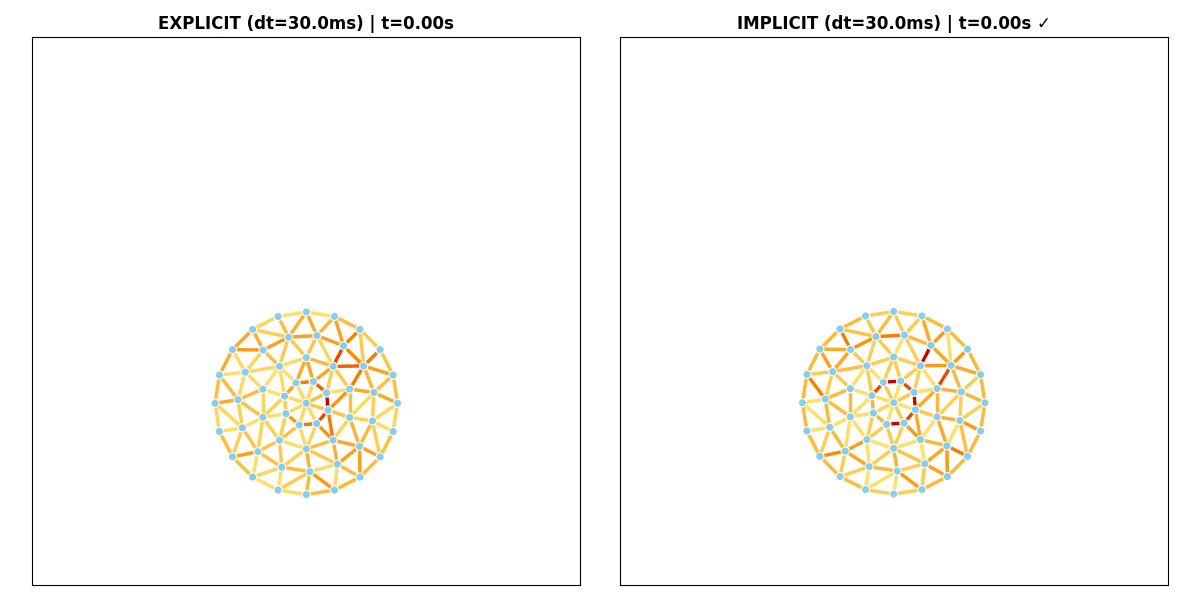

In [9]:
from IPython.display import Image as IPImage
IPImage(filename='implicit_stability_comparison.gif')

---
## 5. Summary

**What we built:**
- Sparse stiffness matrix assembly on GPU using BSR format
- BiCGSTAB linear solver with diagonal preconditioner
- Implicit time integration for springs

**Key Takeaways:**
- **Implicit integration** is unconditionally stable
- The **same parameters** that crash explicit work perfectly with implicit
- Building the stiffness matrix has overhead, but enables much larger timesteps
- Warp's sparse solvers (`bicgstab`, `bsr_set_from_triplets`) make implicit feasible on GPU

**Limitation:** Springs alone cannot preserve **volume** - under compression, the area can collapse!

**Reference:** Baraff & Witkin, "[Large Steps in Cloth Simulation](https://www.cs.cmu.edu/~baraff/papers/sig98.pdf)," SIGGRAPH 1998

**Next:** In [03_fem.ipynb](03_fem.ipynb), we'll add **FEM volumetric forces** to preserve area under compression!